In [1]:
import os
import subprocess
import logging
import sys

def source_lmod_script(script_path):
    """
    Source an Lmod/module script and import environment variables into Python safely,
    suppressing terminal warnings.
    """
    # Use a non-interactive login shell (bash -l), redirect errors
    command = f'bash -l -c "source {script_path} >/dev/null 2>&1; printenv -0"'
    
    proc = subprocess.Popen(command, stdout=subprocess.PIPE, shell=True)
    out, _ = proc.communicate()
    
    # Parse null-separated environment variables
    for env_var in out.split(b'\0'):
        if env_var:
            key, _, value = env_var.partition(b'=')
            os.environ[key.decode()] = value.decode()

# Example usage
M3_BUILD_DIR = "/home/henryi/scratch/venvs/.venv_sbi/bin/"
TUTORIAL_BUILD_DIR = M3_BUILD_DIR
source_lmod_script(f"{M3_BUILD_DIR}/setup.MaCh3.sh")
source_lmod_script(f"{TUTORIAL_BUILD_DIR}/setup.MaCh3Tutorial.sh")
os.environ["OMP_NUM_THREADS"] = "8"


my_stderr = sys.stderr = open('errors.txt', 'w')  # redirect stderr to file
get_ipython().log.handlers[0].stream = my_stderr  # log errors to new stderr
get_ipython().log.setLevel(logging.INFO)  # errors are logged at info level

cat: write error: Broken pipe
cat: write error: Broken pipe


In [2]:
from mach3sbitools.inference.sbi_interface import MaCh3SBIInterface
from mach3sbitools.mach3_interface.mach3_simulator import MaCh3Simulator
from mach3sbitools.utils.logger import MaCh3Logger, get_logger
from mach3sbitools.utils.config import TrainingConfig, PosteriorConfig

import pickle as pkl
from pathlib import Path
import uproot as ur
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
from tqdm import tqdm

import torch
import numpy as np

logger = get_logger("mach3sbitools")
log_level='INFO'
log_file=None
MaCh3Logger("mach3sbitools", level=log_level, log_file=log_file)

In [3]:
inference = MaCh3SBIInterface("Tutorial", Path("/home/henryi/sft/MaCh3Tutorial/TutorialConfigs/FitterConfig.yaml"),
                              cyclical_pars=['delta_cp'])

[Monitor.cpp][info] ##################################
[Monitor.cpp][info] Welcome to:  
[Monitor.cpp][info]   __  __        _____ _     ____  
[Monitor.cpp][info]  |  \/  |      / ____| |   |___ \ 
[Monitor.cpp][info]  | \  / | __ _| |    | |__   __) |
[Monitor.cpp][info]  | |\/| |/ _` | |    | '_ \ |__ < 
[Monitor.cpp][info]  | |  | | (_| | |____| | | |___) |
[Monitor.cpp][info]  |_|  |_|\__,_|\_____|_| |_|____/ 
[Monitor.cpp][info] Version: 2.3.1
[Monitor.cpp][info] ##################################
[Monitor.cpp][info] Using following CPU:
[Monitor.cpp][info] model name	: AMD EPYC 9454 48-Core Processor
[Monitor.cpp][info] cpu MHz		: 3799.238
[Monitor.cpp][info] Architecture:                         x86_64
[Monitor.cpp][info] L1d cache:                            1.5 MiB (48 instances)
[Monitor.cpp][info] L1i cache:                            1.5 MiB (48 instances)
[Monitor.cpp][info] L2 cache:                             48 MiB (48 instances)
[Monitor.cpp][info] L3 cache:         

In [4]:
model_path = Path("/home/henryi/scratch/TutorialTestSBI/models/tutorial_10M_sims/2026-02-26-00-24/tutorial_10M_sims.ts")
# model_path=Path(f"/home/henryi/scratch/TutorialTestSBI/models/tutorial_model_resumed/2026-02-25-01-10_model_resumed/tutorial_model_epoch20500.ts")

posterior_config = PosteriorConfig(
    hidden_features = 256,      # was 50 — scale up to match data volume
    num_transforms= 10,         # was 10 — fewer needed with NSF, less sequential overhead
    dropout_probability= 0.1,  # fine as-is, good regularisation for 5M samples  
    num_blocks= 2,             # fine as-is
    # NSF-specific
    num_bins= 10,             
    # spline bins, 8-12 is the usual sweet spot
)

inference.load_posterior(model_path, posterior_config)
samples = inference.sample_posterior(1000000).cpu()

2026-02-26 07:13:03 INFO     Loading best-model state dict

                    INFO     NPE created | maf | hidden=256 transforms=10 blocks=2 bins=10

                    INFO     Density estimator loaded from                                                         
                             /home/henryi/scratch/TutorialTestSBI/models/tutorial_10M_sims/2026-02-26-00-24/tutoria
                             l_10M_sims.ts

                    INFO     Sampling 1,000,000 points from posterior

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [5]:
# model_path = Path("/home/henryi/scratch/TutorialTestSBI/models/tutorial_10M_sims/2026-02-26-00-24/tutorial_10M_sims.ts")
model_path=Path(f"/home/henryi/scratch/TutorialTestSBI/best_models/256_hidden_20_transforms/tutorial_model.ts")

posterior_config = PosteriorConfig(
    hidden_features = 256,      # was 50 — scale up to match data volume
    num_transforms= 20,         # was 10 — fewer needed with NSF, less sequential overhead
    dropout_probability= 0.1,  # fine as-is, good regularisation for 5M samples  
    num_blocks= 2,             # fine as-is
    # NSF-specific
    num_bins= 10,             
    # spline bins, 8-12 is the usual sweet spot
)

inference.load_posterior(model_path, posterior_config)
samples_other = inference.sample_posterior(1000000).cpu()

2026-02-26 07:13:23 INFO     Loading best-model state dict

                    INFO     NPE created | maf | hidden=256 transforms=20 blocks=2 bins=10

                    INFO     Density estimator loaded from                                                         
                             /home/henryi/scratch/TutorialTestSBI/best_models/256_hidden_20_transforms/tutorial_mod
                             el.ts

                    INFO     Sampling 1,000,000 points from posterior

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [6]:
input_tree = "/home/henryi/sft/MaCh3Tutorial/Test_50m.root"
mach3_chain = ur.open(f"{input_tree}:posteriors").arrays(library="np")

input_tree_short = "/home/henryi/sft/MaCh3Tutorial/Test_NoAdapt.root"
mach3_chain_shorter = ur.open(f"{input_tree_short}:posteriors").arrays(library="np")


In [7]:

def cyclical_to_flat_weights(theta_cyc: torch.Tensor) -> np.ndarray:
    """
    Args:
        theta_cyc: shape (n_samples,) for a single cyclical parameter
    """
    w = 1.0 / (2.0 * torch.sin((theta_cyc + 2.0 * np.pi) / 4.0) ** 2)
    return w.cpu().numpy()

# 4. Normalise weights
dcp_index = inference.simulator.mach3_wrapper.get_parameter_names().index('delta_cp')
weights = cyclical_to_flat_weights(samples[:, dcp_index])
weights_other = cyclical_to_flat_weights(samples_other[:, dcp_index])


In [8]:
dcp_samples = samples[:, dcp_index].clone()
dcp_samples_wrapped = (dcp_samples + np.pi) % (2 * np.pi) - np.pi  # wrap to (-π, π)

dcp_samples_other = samples[:, dcp_index].clone()
dcp_samples_other_wrapped = (dcp_samples + np.pi) % (2 * np.pi) - np.pi  # wrap to (-π, π)


weights = cyclical_to_flat_weights(dcp_samples_wrapped)
weights_other = cyclical_to_flat_weights(dcp_samples_other_wrapped)

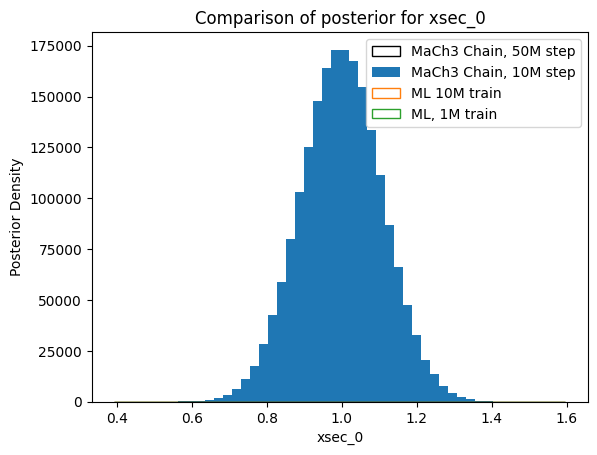

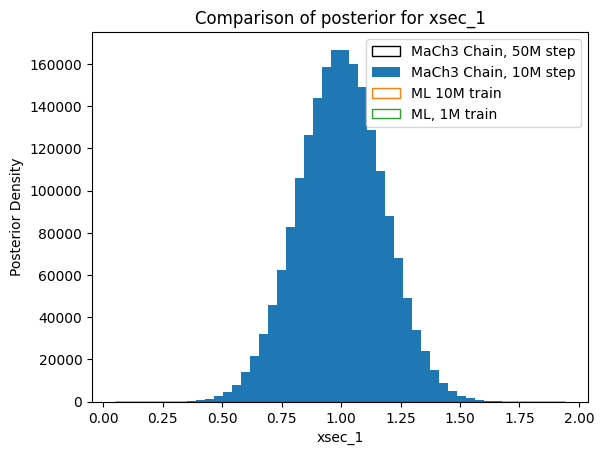

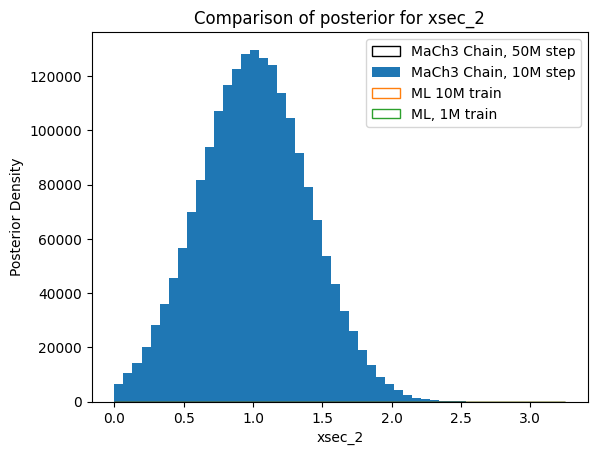

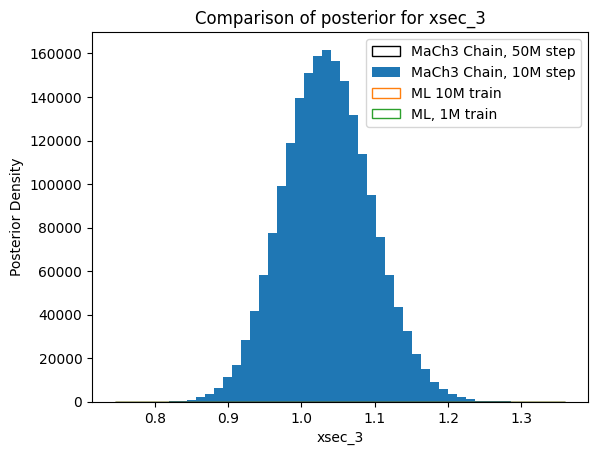

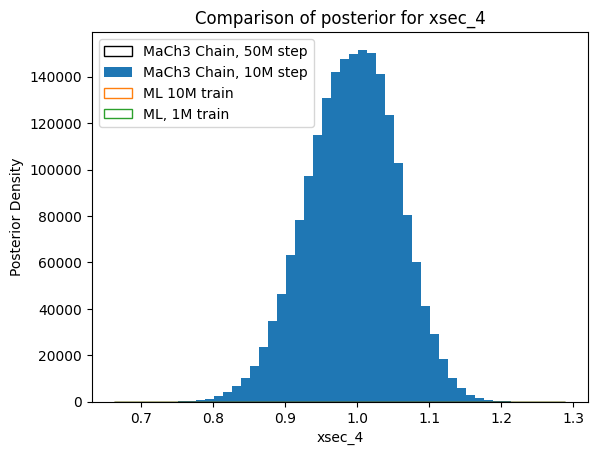

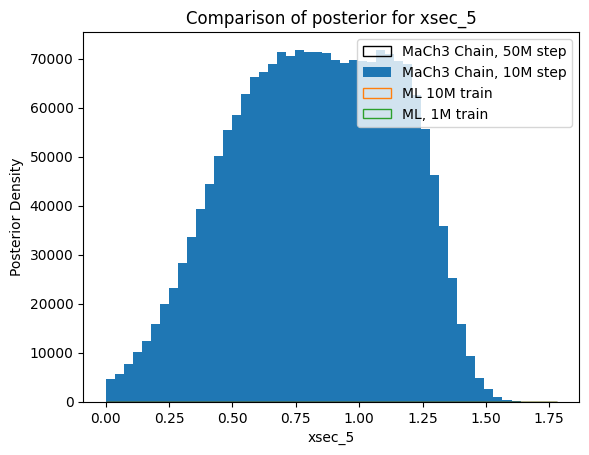

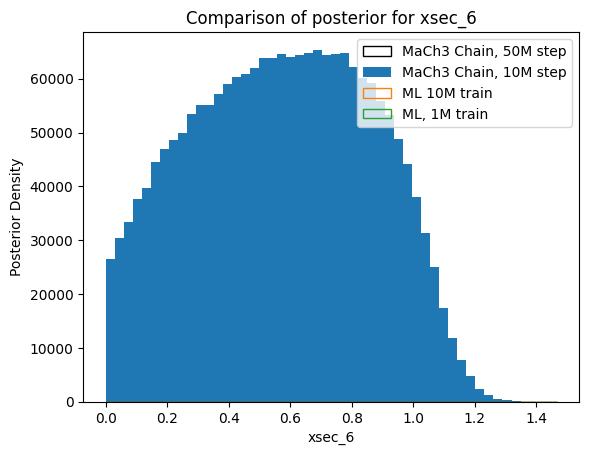

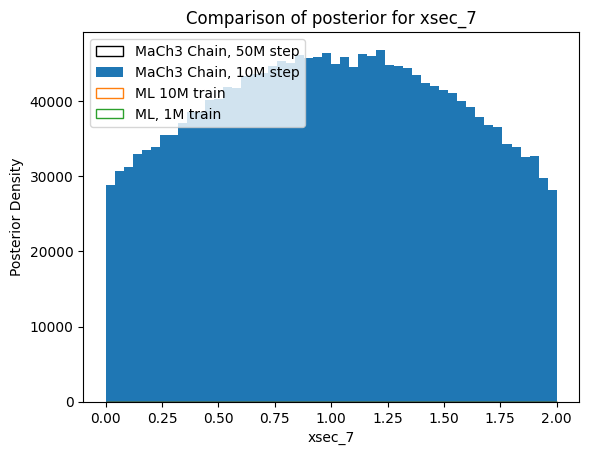

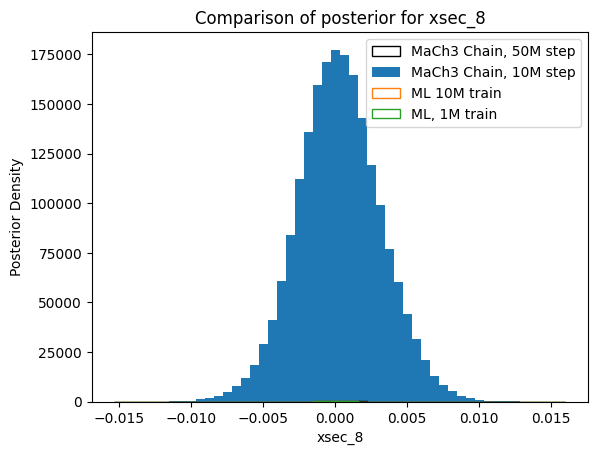

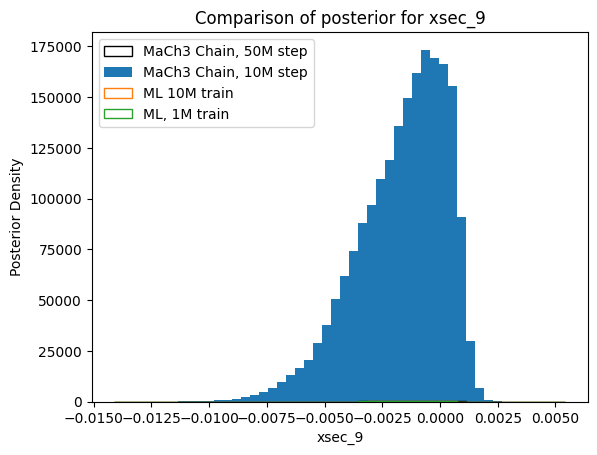

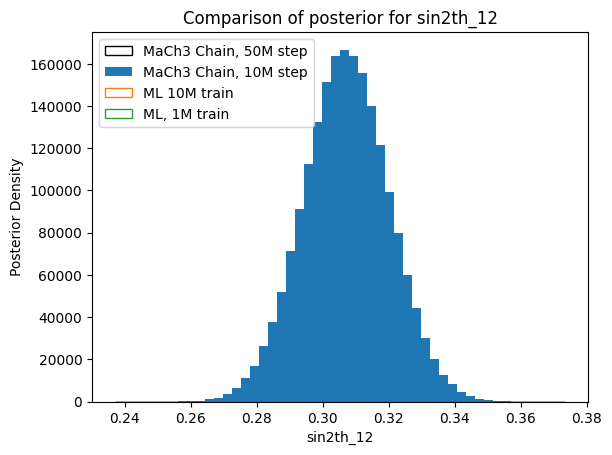

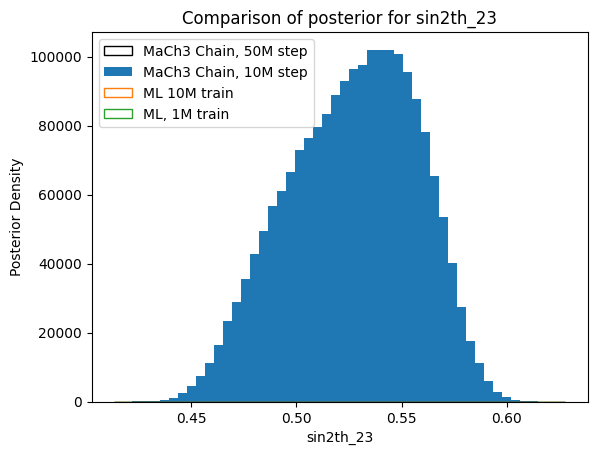

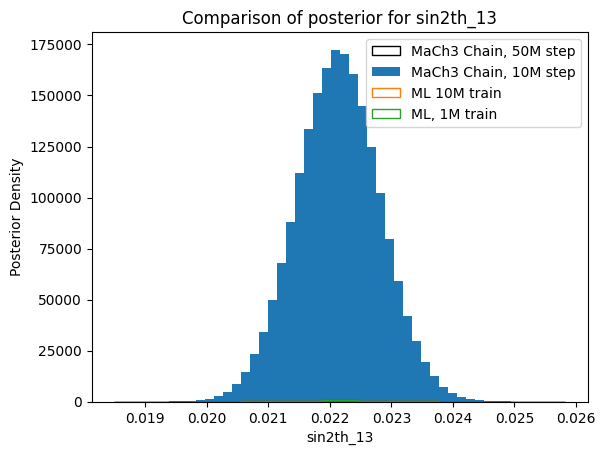

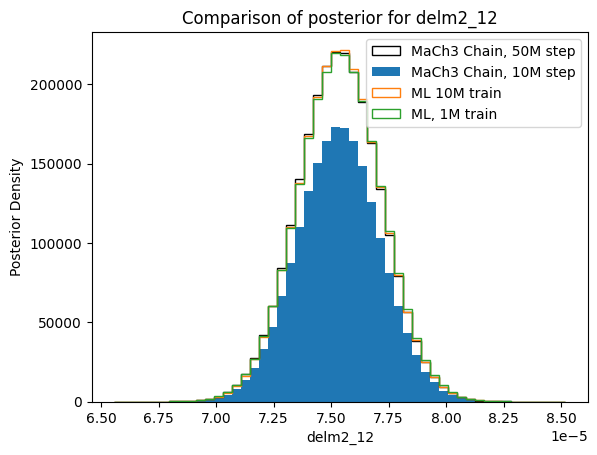

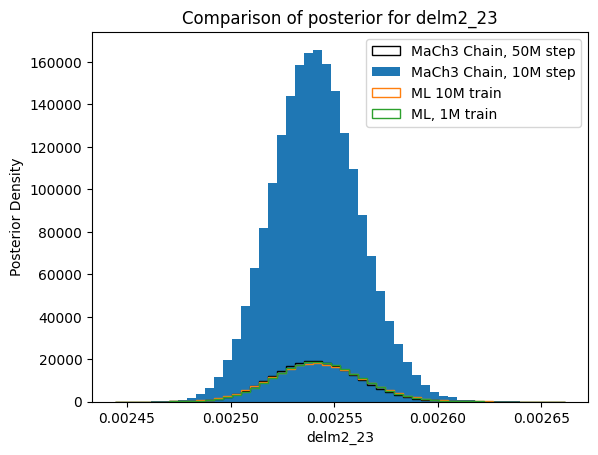

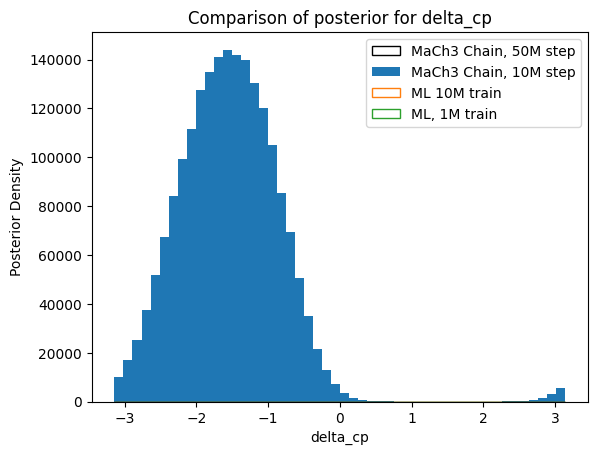

In [9]:
import numpy as np
for i, name in tqdm(enumerate(inference.simulator.mach3_wrapper.get_parameter_names()), total=len(inference.simulator.mach3_wrapper.get_parameter_names())):
    _, bins, _ = plt.hist(mach3_chain[name][10000:], bins=50, density=True, 
                          label="MaCh3 Chain, 50M step", color="k", histtype="step")

    plt.hist(mach3_chain_shorter[name][10000:], bins=bins, label="MaCh3 Chain, 10M step", histtype="step")
    
    sample = samples[:, i].cpu().numpy()
    sample_other = samples_other[:, i].cpu().numpy()
    
    
    if name == 'delta_cp':
        sample = (sample + np.pi) % (2 * np.pi) - np.pi  # wrap for plotting
        sample_other = (sample_other + np.pi) % (2 * np.pi) - np.pi  # wrap for plotting
    
    plt.hist(sample, bins=bins, weights=weights, density=True, label="ML 10M train", histtype="step")
    plt.hist(sample_other, bins=bins, weights=weights_other, density=True, label="ML, 1M train", histtype="step")

    plt.legend()
    plt.xlabel(name)
    plt.ylabel("Posterior Density")
    plt.title(f"Comparison of posterior for {name}")
    plt.show()
    plt.close()